<a href="https://colab.research.google.com/github/hollyemblem/raschka-llm-from-scratch/blob/main/chapter5_pretraining_unlabelled_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## A note on weights and parameters

Weights is used interchangebly with parameters.

Raschka is quite light on detail here, but we can refer back to Kneusel's Math for Deep Learning Book for a more detailed discussion on weights:

> In a traditional NN: if layer i has n nodes and layer i -1 has m outputs, the weight matrix between two layers, Wi. is an n x m matrix. (p.225, Kneusel)

`ai = o(Wi*a(i-1) _b)`

## 5.1 Evaluating generative text models

In [7]:
import torch
import torch.nn as nn


In [8]:
### Adding GeLU to a small feedforward class we'll be using later in TFs.
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


In [9]:
##Implementing the GPT approximation of GELU activation

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        '''
        The GELU activation function can be implemented in several ways;
        the exact version is defined as GELU(x) = x⋅𝛷(x), where 𝛷(x) is the cumulative distribution function of the standard Gaussian distribution.
        In practice, however, it’s common to implement a computationally cheaper approximation
        '''
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [10]:
class LayerNorm(nn.Module):
    '''
    This specific implementation of layer normalization operates on the last dimension of the input tensor x, which represents the embedding dimension (emb_dim).
    The variable eps is a small constant (epsilon) added to the variance to prevent division by zero during normalization.

    Model can adjust scale and shift during training to improve performance - allows for learning appropriate scaling and shift for the task.
    '''

    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim)) #trainable parameter
        self.shift = nn.Parameter(torch.zeros(emb_dim)) #trainable parameter

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False) ##Setting to true uses Besset's correction to adjust for bias and is n-1 in denominator, not n.
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [11]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out,
                 context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads" ##This is key for the splits below

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads    #1 reduces projection dimension to desired output
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)    #2 use a linear layer to cmbine outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        batch_size, num_tokens, d_in = x.shape
        keys = self.W_key(x)         #3 compute keys
        queries = self.W_query(x)    #3 compute queries
        values = self.W_value(x)     #3 compute values

        keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim)       #4 #split matrix by adding a number of heads value
        values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(
            batch_size, num_tokens, self.num_heads, self.head_dim
        )

        keys = keys.transpose(1, 2)          #5 Transpose for multiplication
        queries = queries.transpose(1, 2)    #5 Transpose for multiplication
        values = values.transpose(1, 2)      #5 Transpose for multiplication
        attn_scores = queries @ keys.transpose(2, 3)   #6 for product per head
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]    #7

        attn_scores.masked_fill_(mask_bool, -torch.inf)     #8 mask tokens - fill attention scores

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)   #9 calculate the context  vector
                                                          #10 Combine the heads

        '''
        The context vectors from all heads are transposed back to the shape (b, num_tokens, num_heads, head_dim).
        These vectors are then reshaped (flattened) into the shape (b, num_tokens, d_out), effectively combining the outputs from all heads.
        '''
        context_vec = context_vec.contiguous().view(
            batch_size, num_tokens, self.d_out
        )
        context_vec = self.out_proj(context_vec)    #11 linear projection of context vector
        return context_vec

In [12]:


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
 #1
        shortcut = x #shortcut for attention block
        x = self.norm1(x) ## Pre-LayerNorm; added before attention, dropout. PostLayerNorm would add after.
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut      # add layers

        shortcut = x         #3 shortcut for feedforward block
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut      #4 add layers: 'adds the input of the block to its output'
        return x

In [13]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
 #1
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x) ##apply dropout
        x = self.trf_blocks(x) ##apply transformer blocks
        x = self.final_norm(x) ##last normalisation
        logits = self.out_head(x) ##linear layer to get unnormalised probabilities of next word
        return logits

In [14]:
## Use GPT to generate text

import torch

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,    #1
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,       #2
    "qkv_bias": False
}
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [15]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

In [16]:
## Text generation function
def generate_text_simple(model, idx,                 #1  array of indices in the current context.
                         max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]    #2 Crops current context if it exceeds the supported context size, e.g., if LLM supports only 5 tokens, and the context size is 10, then only the last 5 tokens are used as context
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]                    #3 Focuses only on the last time step, so that (batch, n_token, vocab_size) becomes (batch, vocab_size)
        probas = torch.softmax(logits, dim=-1)           #4 Convert logits to probabilities
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)    #5 Obtain position of top token
        idx = torch.cat((idx, idx_next), dim=1)     #6 Concatenate the token to the running sequence
        print(tokenizer.decode(idx_next.squeeze(0).tolist()))

    return idx

In [17]:
#utility functions
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)    #1
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)                #2
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

 renting
etic
 wasn
م
 refres
 Rex
Me
CH
icular
 stren
Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


## Introducing a loss metric

Implementing a loss metric for the outputs; minimising this loss gets us closer to our goal of high quality text outputs.

We want to measure the distance between the target and our outputs, and increase the softmax probability in the index positions corresponding to correct target token IDs.

We use this information (the distance) to adjust the weights to minimise the loss and generate text that's closer to the target.

#### A high-level look at the text generation process:

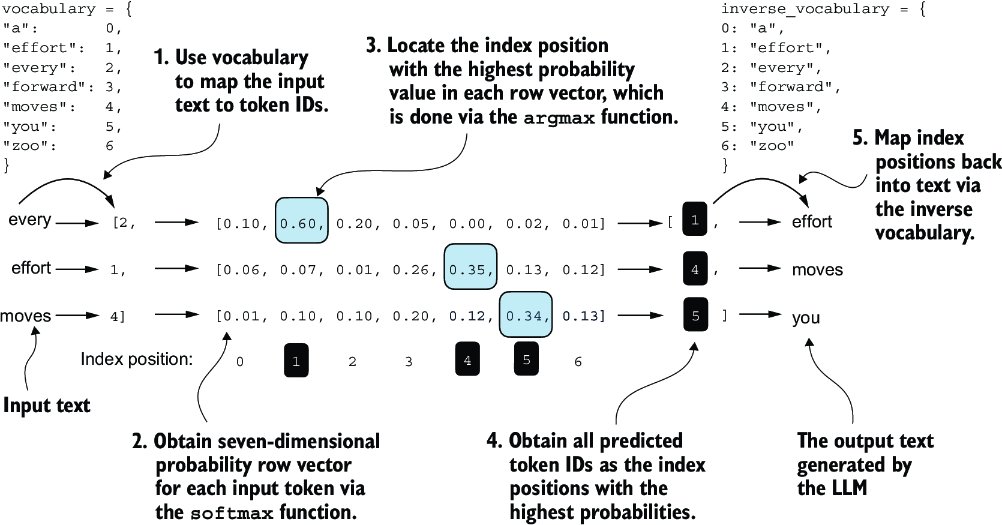

> For each of the three input tokens, shown on the left, we compute a vector containing probability scores corresponding to each token in the vocabulary. The index position of the highest probability score in each vector represents the most likely next token ID. These token IDs associated with the highest probability scores are selected and mapped back into a text that represents the text generated by the model.

In [18]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

In [19]:
targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107, 588, 11311]])  #  " really like chocolate"]

In [20]:
with torch.no_grad():     #1
    logits = model(inputs) #get the logits
probas = torch.softmax(logits, dim=-1)     #2convert to probabilities
print(probas.shape) #The first number =  batch size. The second number, 3,= number of tokens in each input (row). 50257 = corresponds to the embedding dimensionality, which is determined by the vocabulary size.

torch.Size([2, 3, 50257])


In [21]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [22]:
## Tokens to text
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"
      f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


#### Evaluating the performance of the model

For text evaluation, we want to measure how far the predictions are from the target.

With training we aim to increase the softmax probability associated with the IDs for target terms. Softmax is also used as an evaluation metric. The higher the probability associated with the correct positions, the better.


> "The goal of training an LLM is to maximize the likelihood of the correct token, which involves increasing its probability relative to other tokens"


In [23]:
### Printing initial softmax probabilities

text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


#### What are the key steps to calculating loss?

1. Obtain logits
2. Obtain probabilities
3. Get target probabilities
4. Obtain log probabilities
5. Average log probability
6. Obtain negative average log probability (this is what we use). <- Also known as cross-entropy loss.

Why use log probabilities? More manageable mathematically and covered in a lecture - Review.

In [24]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [25]:
#Compute single score
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


In [26]:
# Bring the log probability mean into negative.
'''
However, in deep learning, the common practice isn’t to push the average log probability up to 0
but rather to bring the negative average log probability down to 0.
The negative average log probability is simply the average log probability multiplied by –1,
'''
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas) #This is also known as cross-entropy loss

tensor(10.7940)


#### What is cross-entropy loss?


Measures the distance between two probability distributions- true distributoon of labels (true tokens) and predicted distribution from a model (token probabilities).

In [27]:
logits_flat = logits.flatten(0, 1) #flatten logits
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [28]:
##Steps 2-6 are covered by cross-entropy loss here

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


#### What is perplexity?


Measures how well probability distro predicted by the model matches the actual distribution of words in the dataset. Lower perplexity = model predictions are closer to actual distro.


Differing to cross-entropy,  gives you data on the effective vocab size that the model isn't sure of in each step.

In [29]:
##calculating perplexity

perplexity = torch.exp(loss)

In [30]:
perplexity

tensor(48725.8203)

### Calculating Training and Validation Set Losses

In [31]:
## Loading in the Verdict short story
import urllib.request
url = ("https://raw.githubusercontent.com/rasbt/"
       "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
       "the-verdict.txt")
file_path = "the-verdict.txt"
urllib.request.urlretrieve(url, file_path)

('the-verdict.txt', <http.client.HTTPMessage at 0x79e33c542690>)

In [32]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

In [33]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


#### Data Loader Preparation

1. Split the input text into training and validation.
2. Tokenize the text, and divide into user-specified chunks
3. Shuffle rows and organize chunk text into batches (user specified batch size)

In [34]:
#Train/test split
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [35]:
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
    '''The GPTDatasetV1 class is based on the PyTorch Dataset class and defines how individual rows are fetched from the dataset, '''
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)    #1 Tokenizes the entire text

        for i in range(0, len(token_ids) - max_length, stride):     #2 Uses a sliding window to chunk the book into overlapping sequences of max_length
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):    #3 Returns the total number of rows in the dataset
        return len(self.input_ids)

    def __getitem__(self, idx):         #4 Returns a single row from the dataset
        return self.input_ids[idx], self.target_ids[idx]

In [36]:
#Data loader from chapter 2: https://github.com/hollyemblem/raschka-llm-from-scratch/blob/main/chapter2_data_sampling_with_sliding_window.ipynb
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")                         #1 Initializes the tokenizer
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)   #2 Creates dataset
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,     #3 drop_last=True drops the last batch if it is shorter than the specified batch_size to prevent loss spikes during training.
        num_workers=num_workers     #4 The number of CPU processes to use for preprocessing
    )

    return dataloader

In [37]:

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [38]:
# Calculate cross-entropy loss
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)         #1
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

In [39]:
#Compute the loss for a single batch
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)     #1 iterate over all batches if no fixed number is provided
    else:
        num_batches = min(num_batches, len(data_loader))   #2  Reduces the number of batches to match the total number of batches in the data loader if num_batches exceeds the number of batches in the data loader
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()    #3 cumulate loss
        else:
            break
    return total_loss / num_batches    #4 calculate averave loss

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)   #1
with torch.no_grad():                                        #2
    train_loss = calc_loss_loader(train_loader, model, device)    #3
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.98758347829183
Validation loss: 10.98110580444336


In [41]:
##Our loss is quite high as we haven't trained our model yet!

## Training an LLM

At a high-level, the steps for training an LLM are as follows:

1. Iterate over training epochs
2. Iterate over batches per training epoch.
3. Reset loss gradients from prev. batch
4. Calculate the loss on the current batch.
5. Backward pass to calculate the loss gracients
6. Update model weights using loss gradients


Optional steps:

7. Review training/validation loss

8. Visually inspect text

In [42]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()  #1 disable dropout
    with torch.no_grad():                              #2 disable gradient tracking
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [43]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [44]:
## Pre-training LLMs function
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []    #1 lists to track loss and tokens
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()   #3 reset loss gradients
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()                     #4 back propagate loss
            optimizer.step()                    #5 update model weights
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:    #6 eval step
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        generate_and_print_sample(                      #7 review tokens
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen



In [ ]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
     model.parameters(),           #1 use adamw for gradient descent
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.781, Val loss 9.933
Ep 1 (Step 000005): Train loss 8.111, Val loss 8.339
,
,
,
,
,
,
,
,
,
,
,
,
.










































































Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.661, Val loss 7.048
Ep 2 (Step 000015): Train loss 5.961, Val loss 6.616
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
 and
,
,
 and
,
 and
,
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.726, Val loss 6.600
Ep 3 (Step 000025): Train loss 5.201, Val loss 6.348


In [ ]:
## Review training and validation loss
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()                   #1
    ax2.plot(tokens_seen, train_losses, alpha=0)     #2
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## 5.3 Decoding strategies to control randomness

Looking at text generation (decoding) strategies. Here's the two we are examining:
1. Temperature scaling
2. Top-k sampling



In [ ]:
# For inference move back to CPU
model.to("cpu")
model.eval()

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")
''' The generated token is selected at each generation step corresponding to the largest probability score among all tokens in the vocabulary.
    This means that the LLM will always generate the same outputs even if we run the preceding generate_text_simple function multiple times on the same start context '''
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))